<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/epsilon_greedy_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos $\epsilon$-greedy y $\epsilon$-decay en un problema de k-armed bandit utilizando brazos con distribuciones normales. Se generan gráficas de recompensas promedio, rechazo acumulado y porcentaje de elección de la opción óptima para cada algoritmo.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/14

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


Primero copiamos nuestro repositorio.

In [1]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git


Cloning into 'FernandezMartinezPolo-EML-RL'...


In [2]:
!cd FernandezMartinezPolo-EML-RL/

In [3]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/FernandezMartinezPolo-EML-RL/k_brazos/src')
sys.path.append('./src')

# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecay
from arms import ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


['C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\Lib', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311', 'c:\\Users\\angel\\Desktop\\Master-Practicas-Repos\\FernandezMartinezPolo-EML-RL\\.venv', '', 'c:\\Users\\angel\\Desktop\\Master-Practicas-Repos\\FernandezMartinezPolo-EML-RL\\.venv\\Lib\\site-packages', './src']


## Experimento

En este notebook se analiza un problema de bandido multi-brazo de 10 brazos, donde cada brazo sigue una distribución normal. Se implementan tres variantes del algoritmo $\epsilon$-greedy y tres variantes del algoritmo $\epsilon$-decay, utilizando distintos valores del parámetro $\epsilon$ en el algoritmo $\epsilon$-greedy, y distintos tipos de decaimiento en el algoritmo $\epsilon$-decay.

Cada política se evalúa a lo largo de 2000 iteraciones, y todo el experimento se repite 500 veces de forma independiente. En cada iteración se calcula la media de las recompensas obtenidas considerando esas 500 ejecuciones.

La comparación entre algoritmos se realiza utilizando varias métricas: recompensa media, proporción media de selecciones óptimas y arrepentimiento acumulado medio.

In [4]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar los rechazos promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms] #Para las arm stats

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        sum_current_run_expected_value = np.zeros(len(algorithms)) # Aquí se almacena el valor esperado acumulado para cada algoritmo de esta run. Necesario para calcular el rechazo

        for idx, algo in enumerate(algorithms):
          for step in range(steps):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward # Actualizar la ganancia del brazo seleccionado por el algoritmo.
                arm_stats[idx]['selections'][chosen_arm] += 1 # Actualizar el número de selecciones del brazo seleccionado por el algoritmo.

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Modificar optimal_selections cuando el brazo elegido se corresponde con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Si el step actual es 0, el valor esperado acumulado se inicializa con el valor esperado del brazo
                # elegido actualmente. Si no, se suma el valor esperado del brazo actual al valor acumulado
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] = sum_current_run_expected_value[idx] + bandit.get_expected_value(chosen_arm)

                #regrets[idx, step] = regrets[idx, step-1] + (bandit.get_expected_value(optimal_arm) - reward) if step > 0 else bandit.get_expected_value(optimal_arm) - reward
                regrets[idx, step] += (step+1)*bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = optimal_selections*100/runs

    for stat in arm_stats:
        stat['mean_rewards'] /= runs
        stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats


## Ejecución del experimento

Se diseña un experimento sobre un problema de bandido multi-brazo con 10 acciones posibles, donde las recompensas asociadas a cada brazo siguen una distribución de bernoulli. Para garantizar la estabilidad estadística de los resultados, el experimento se repite 500 veces, realizando en cada repetición una simulación de 1000 iteraciones. En este contexto se evalúan tres configuraciones diferentes de algoritmos basados en $\epsilon$-greedy, y seis configuraciones diferentes de algoritmos basados en $\epsilon$-decay. Estos algoritmos se basan en elegir la opción que se considera que va a ofrecer una mayor recompensa según los datos vistos por el propio algoritmo, aunque explorando otra opción aleatoria con probabilidad $\epsilon$. Es importante destacar que estos algoritmos realizan un recorrido inicial para tener un primer vistazo de las recompensas presentes en cada uno de los brazos a elegir, pudiendo así elegir de forma voraz el que ha proporcionado mejores recompensas.

Mientras que en el algoritmo $\epsilon$-greedy el valor de $\epsilon$ se mantiene constante, en el algoritmo $\epsilon$-decay el valor inicial de $\epsilon$ (es decir, $\epsilon_0$) disminuye progresivamente conforme avanza la ejecución utilizando un parámetro $\lambda$. Este parámetro representa la tasa de decaimiento, es decir, cuánto disminuye $\epsilon$ en cada paso temporal. Una vez llegado a un valor mínimo ($\epsilon_{min}$), el valor de $\epsilon$ no disminuye más. Dependiendo del tipo de decaimiento utilizado, se empleará una fórmula u otra para calcular el nuevo valor de $\epsilon$ en cada paso temporal:

**Decaimiento lineal:**

$$f(t, \epsilon_0, \lambda) = \epsilon_0 - t \cdot \lambda$$

**Decaimiento exponencial:**

$$f(t, \epsilon_0, \lambda) = \epsilon_0 \cdot e^{-\lambda t}$$

**Decaimiento inversamente proporcional:**

$$f(t, \epsilon_0, \lambda) = \frac{\epsilon_0}{1 + \lambda t}$$

En los tres tipos de decaimiento se toma como valor de $\epsilon$ en cada paso temporal $\epsilon_t = máx(\epsilon_{min}, f(t, \epsilon_0, \lambda))$. Es decir, hay una probabilidad de $\epsilon_t$ en cada paso temporal de seleccionar una acción aleatoria, en vez de seleccionar la mejor opción de manera voraz.

En los experimentos realizados se utilizan tres valores del parámetro $\epsilon$ en el algoritmo $\epsilon-greedy$. En el caso del algoritmo $\epsilon-decay$, se utilizan dos valores de $\epsilon$, dos valores de $\lambda$ y los tres tipos de decaimiento, fijando $\epsilon_{min}$ en 0.01. De esta forma, se evalúa cómo distintos niveles de exploración afectan al rendimiento de los algoritmos.

Los parámetros exactos que se han utilizado han sido los siguientes:

- **$\epsilon$-greedy:**
  - $\epsilon$-greedy con $\epsilon=0$
  - $\epsilon$-greedy con $\epsilon=0.01$
  - $\epsilon$-greedy con $\epsilon=0.1$

- **$\epsilon$-decay:**
  - $\epsilon$-decay con decaimiento lineal y $\epsilon=0.5,\ \epsilon_{min}=0.01,\ \lambda = 0.001$
  - $\epsilon$-decay con decaimiento exponencial y $\epsilon=0.5,\ \epsilon_{min}=0.01,\ \lambda = 0.001$
  - $\epsilon$-decay con decaimiento inverso y $\epsilon=0.5,\ \epsilon_{min}=0.01,\ \lambda = 0.001$

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución de bernoulli con $p \in [0,1]$. Se realizan 500 ejecuciones de 2000 pasos cada una.

In [5]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 2000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar.
algorithms = [EpsilonGreedy(k=k, epsilon=0),
              EpsilonGreedy(k=k, epsilon=0.01),
              EpsilonGreedy(k=k, epsilon=0.1),

              EpsilonDecay(k=k, epsilon=0.5, epsilon_min=0, decay_lambda=0.001, decay_type="lin"),
              EpsilonDecay(k=k, epsilon=0.5, epsilon_min=0, decay_lambda=0.001, decay_type="exp"),
              EpsilonDecay(k=k, epsilon=0.5, epsilon_min=0, decay_lambda=0.001, decay_type="inv"),]
# Ejecutar el experimento y obtener las recompensas promedio, rechazo acumulado y promedio de las selecciones óptimas
rewards, regrets, optimal_selections, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


Ahora exportamos los resultados para poder luego generar una gráfica conjuntamente con los otros algoritmos.

In [ ]:
import os

# Create a directory to store the exported data
output_dir = 'exported_data'
os.makedirs(output_dir, exist_ok=True)

# Export data for Normal Distribution
np.savez(os.path.join(output_dir, 'egreedy_normal_data.npz'),
         rewards=rewards,
         regrets=regrets,
         optimal_selections=optimal_selections)
print(f"Normal experiment data saved to {os.path.join(output_dir, 'egreedy_normal_data.npz')}")

## Visualización de los resultados

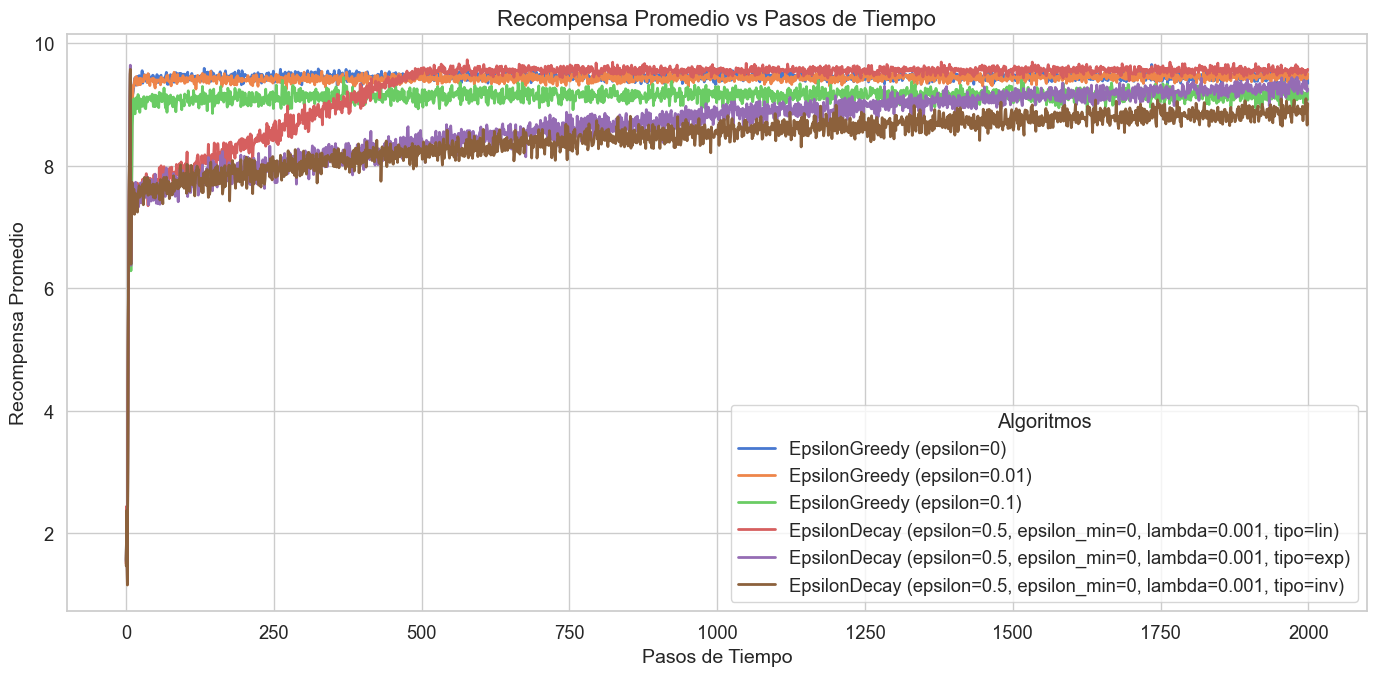

In [6]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se compara el comportamiento de distintas configuraciones de los algoritmos **$\epsilon$-greedy** y **$\epsilon$-decay**. En el eje **x** aparecen los **pasos de tiempo**, mientras que en el eje **y** se representa la **recompensa promedio** obtenida por cada política a lo largo del proceso de aprendizaje.

**1. Interpretación de las líneas del gráfico**

En la gráfica aparecen seis curvas: tres de ellas corresponden a configuraciones distintas del algoritmo $\epsilon$-greedy, y las otras tres corresponden a configuraciones del algoritmo $\epsilon$-decay. Todas ellas suben y bajan de forma errática en los primeros pasos temporales, representando la etapa inicial de exploración de cada uno de los brazos, donde se eligen los k brazos en orden para tener una primera estimación de las recompensas que cada uno de estos proporciona.

**2. Evolución de la recompensa promedio**

Algunos de los algoritmos consiguen converger rápidamente a una solución, mientras que otros necesitan algo más de tiempo para estabilizar la recompensa promedio obtenida.

Los algoritmos sin decaimiento son los que convergen más deprisa, pues tienen valores menores de $\epsilon$, consiguiendo recompensas alrededor de 9, las cuales son muy buenas teniendo en cuenta que el brazo óptimo tiene una recompensa esperada de 9,56.

Por otra parte, los algoritmos con decaimiento, al comenzar con valores altos de $\epsilon$, tardan más en converger. De estos, el algoritmo que utiliza un decaimiento lineal es el que más rápido converge, obteniendo los mejores resultados. Esto se debe a que, en un principio, el valor de $\epsilon$ es muy elevado (0.5), por lo que el algoritmo explora con bastante frecuencia. Conforme el valor de $\epsilon$ disminuye, el algoritmo realiza cada vez más explotación que exploración, consiguiendo así un valor cada vez más elevado de recompensa promedio, hasta que converge una vez $\epsilon$ llega al valor mínimo (0).

**3. Conclusiones**

Este gráfico muestra cómo todos los algoritmos obtienen recompensas buenas y cercanas a la recompensa esperada del brazo óptimo. Los algoritmos de $\epsilon$-decay tardan más en converger, pero esto no impide que también obtengan buenas recompensas promedio.

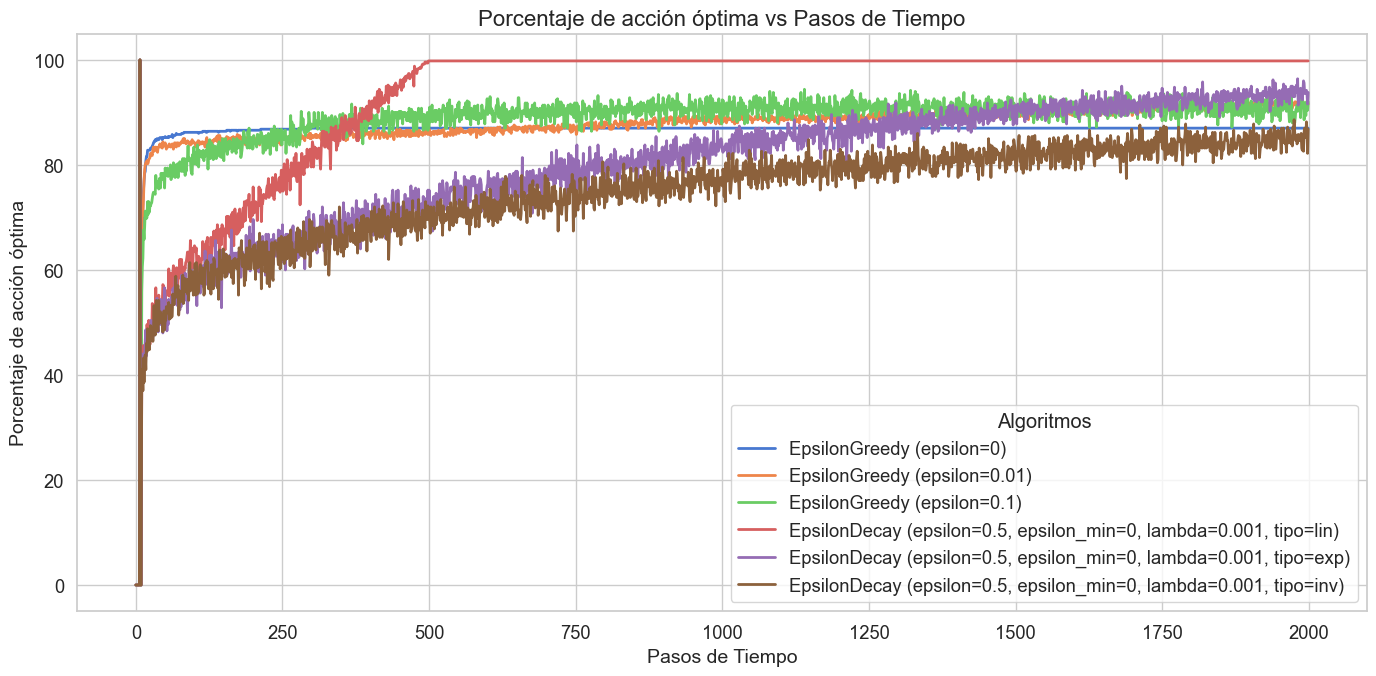

In [7]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Porcentaje de acción óptima vs Pasos de Tiempo"**, donde se compara el rendimiento de distintas configuraciones de los algoritmos **$\epsilon$-greedy** y **$\epsilon$-decay**. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de veces que se selecciona la acción óptima**.

**1. Interpretación de las líneas del gráfico**

Al igual que en la gráfica anterior, en esta aparecen seis curvas: tres de ellas correspondientes a configuraciones distintas del algoritmo $\epsilon$-greedy, y otras tres correspondientes a configuraciones del algoritmo $\epsilon$-decay. Aquí también se aprecia una primera etapa de bajadas y subidas, correspondientes a la etapa de exploración de cada brazo para tener una estimación inicial de las recompensas.

**2. Evolución del porcentaje de acción óptima**

Todas las configuraciones muestran un aumento progresivo en el porcentaje de selección de la acción óptima, lo que indica aprendizaje efectivo del mejor brazo. Sin embargo, no todos los algoritmos tardan lo mismo en converger a una solución, y no todos los que convergen rápido pueden encontrar el brazo óptimo con la misma facilidad.

**Algoritmos $\epsilon$-greedy — Líneas azul, naranja y verde**

Estas configuraciones consiguen una rápida convergencia a costa de un porcentaje de selección óptima no tan alto como los algoritmos $\epsilon$-decay. En el caso de $\epsilon=0$ se tiene un porcentaje fijo de seleción óptima de más del 80%, mientras que en las configuraciones con valores de $\epsilon$ distintas de 0 se consiguen porcentajes de alrededor de 90%.

**Algoritmo $\epsilon$-decay con decaimiento lineal — Línea roja**

Esta configuración es la que más rápido converge de las configuraciones $\epsilon$-decay, y la que mejor porcentaje de selección óptima consigue tras converger: un 100% tras 500 pasos temporales. Esto tiene sentido, pues con un $\epsilon$ de 0.5 comienza explorando con mucha frecuencia. Conforme avanza la ejecución, el decaimiento lineal causa que el valor de $\epsilon$ disminuya más rápidamente que con los otros dos tipos de decaimiento, permitiendo pasar rápidamente de explorar frecuentemente a explotar cada vez más. Al terminar la fase de exploración y llegar $\epsilon$ a 0, durante la fase de explotación es posible encontrar y elegir constantemente el brazo óptimo gracias a todos los resultados que se han obtenido durante la exploración intensiva realizada anteriormente.

**Algoritmos $\epsilon$-decay con decaimiento exponencial e inversamente proporcional — Líneas morada y marrón**

Estas configuraciones tardan bastante en converger debido a su tipo de decaimiento. Mientras que el decaimiento lineal permite disminuir rápidamente el valor de $\epsilon$, los decaimientos exponencial e inversamente proporcional decrementan su valor más lentamente, ralentizando la convergencia. Si bien es cierto que la configuración con decaimiento exponencial consigue superar a las configuraciones sin decaimiento, también es cierto que esto ocurre bastante tarde, tras muchos pasos temporales. En este aspecto el decaimiento lineal ha demostrado ser más efectivo, consiguiendo una convergencia más rápida y unos resultados mejores.


**3. Conclusiones**

El gráfico refleja la importancia del equilibrio entre la exploración y la explotación. Los algoritmos sin decaimiento convergen rápido, pero se quedan estancados en resultados subóptimos. Los algoritmos con decaimiento exponencial e inversamente proporcional tardan mucho en converger. Por encima de todos estos se encuentra el algoritmo con decaimiento lineal, que ofrece una rápida convergencia y unos resultados insuperables tras 500 pasos temporales, logrando encontrar con total certeza el brazo óptimo.

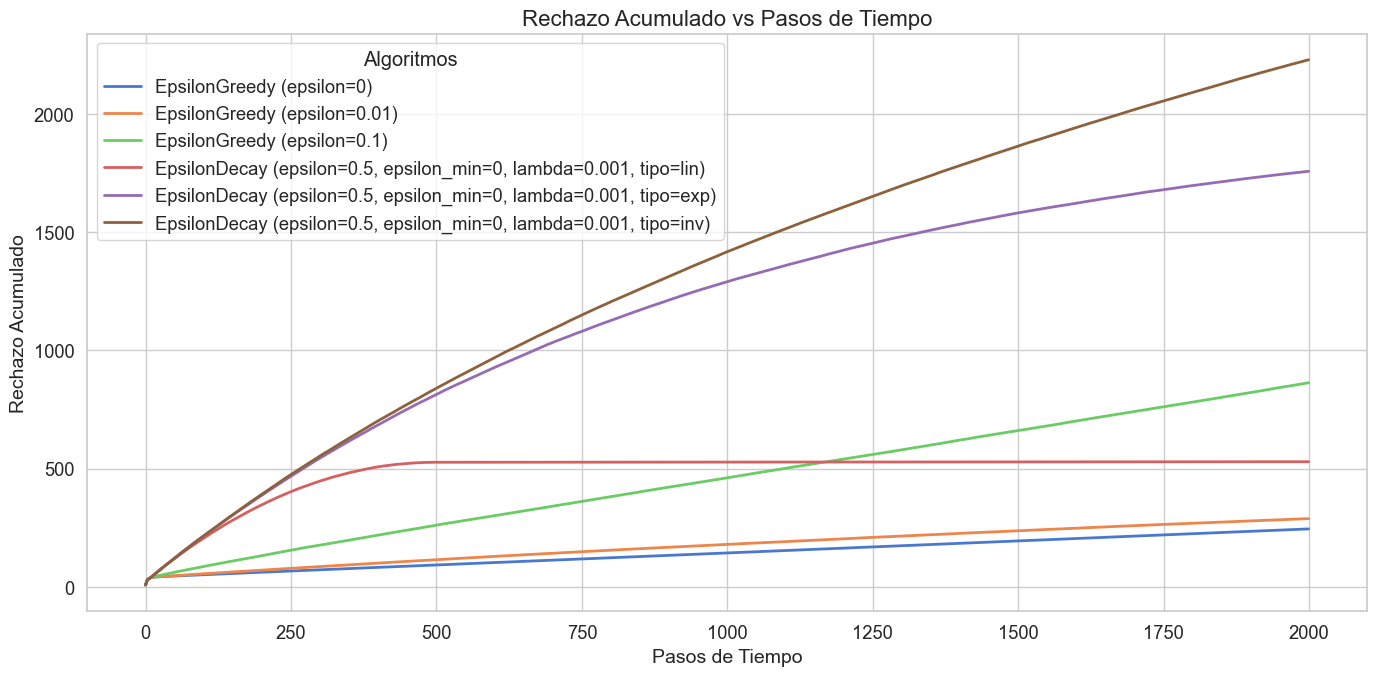

In [8]:
plot_regret(steps, regrets, algorithms)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Rechazo Acumulado vs Pasos de Tiempo"**, donde se compara el rendimiento de distintas configuraciones de los algoritmos **$\epsilon$-greedy** y **$\epsilon$-decay**. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **rechazo acumulado**, que mide la pérdida total respecto a la recompensa que se habría obtenido seleccionando siempre la acción óptima.

**1. Interpretación de las líneas del gráfico**

En la gráfica aparecen seis curvas: tres de ellas correspondientes a configuraciones distintas del algoritmo $\epsilon$-greedy, y otras tres correspondientes a configuraciones del algoritmo $\epsilon$-decay.

**2. Evolución global del rechazo acumulado**

El rechazo acumulado crece con el número de pasos para casi todos los algoritmos. Cuanto más crece, peores son los brazos que se están eligiendo (es decir, peor es su recompensa esperada con respecto a la recompensa esperada del brazo óptimo). Según cómo evoluciona la pendiente de cada curva es posible analizar el rendimiento de cada algoritmo:

**Algoritmos $\epsilon$-greedy — Líneas azul, naranja y verde**

Estos algoritmos se quedan atascados seleccionando brazos subóptimos, lo cual se representa con pendientes constantes. A pesar de utilizar $\epsilon$ para intentar explorar otros brazos, estos algoritmos no parecen ser capaces de encontrar el brazo óptimo con facilidad.

**Algoritmos $\epsilon$-decay con decaimiento exponencial e inversamente proporcional — Líneas marrón y morada**

La lenta convergencia de estos algoritmos es reflejada en su alto rechazo. Si bien es cierto que la pendiente cada vez se hace menos pronunciada (indicando que los algoritmos están convergiendo a la solución óptima), tardan mucho en hacerlo, y mientras lo hacen están seleccionando con mucha frecuencia brazos subóptimos.

**Algoritmo $\epsilon$-decay con decaimiento lineal — Línea roja**

Este algoritmo comienza con un rechazo mayor al de los algoritmos sin decaimiento, pero converge rápidamente hasta conseguir encontrar el brazo óptimo sin problemas, lo cual es representado por una curva completamente plana a partir del paso temporal 500. Mientras que el rechazo acumulado de los algoritmos sin decaimiento sigue creciendo, el de este algoritmo se mantiene constante, demostrando haber sido capaz de aprender información útil durante la fase de exploración.

### **3. Conclusiones**

Este gráfico muestra el impacto del nivel de exploración sobre el rechazo acumulado. Los algoritmos sin decaimiento consiguen un menor rechazo acumulado en el corto plazo, pero conforme avanza la ejecución se observa cómo el rechazo acumulado de los algoritmos con decaimiento comienza a disminuir mientras que el de los algoritmos sin decaimiento sigue aumentando. Destaca el algoritmo con decaimiento lineal, consiguiendo mantener su rechazo acumulado constante tras 500 pasos temporales, demostrando su capacidad para encontrar el brazo óptimo tras una intensa etapa inicial de exploración.

### Ganancia promedio y número de selecciones por brazo

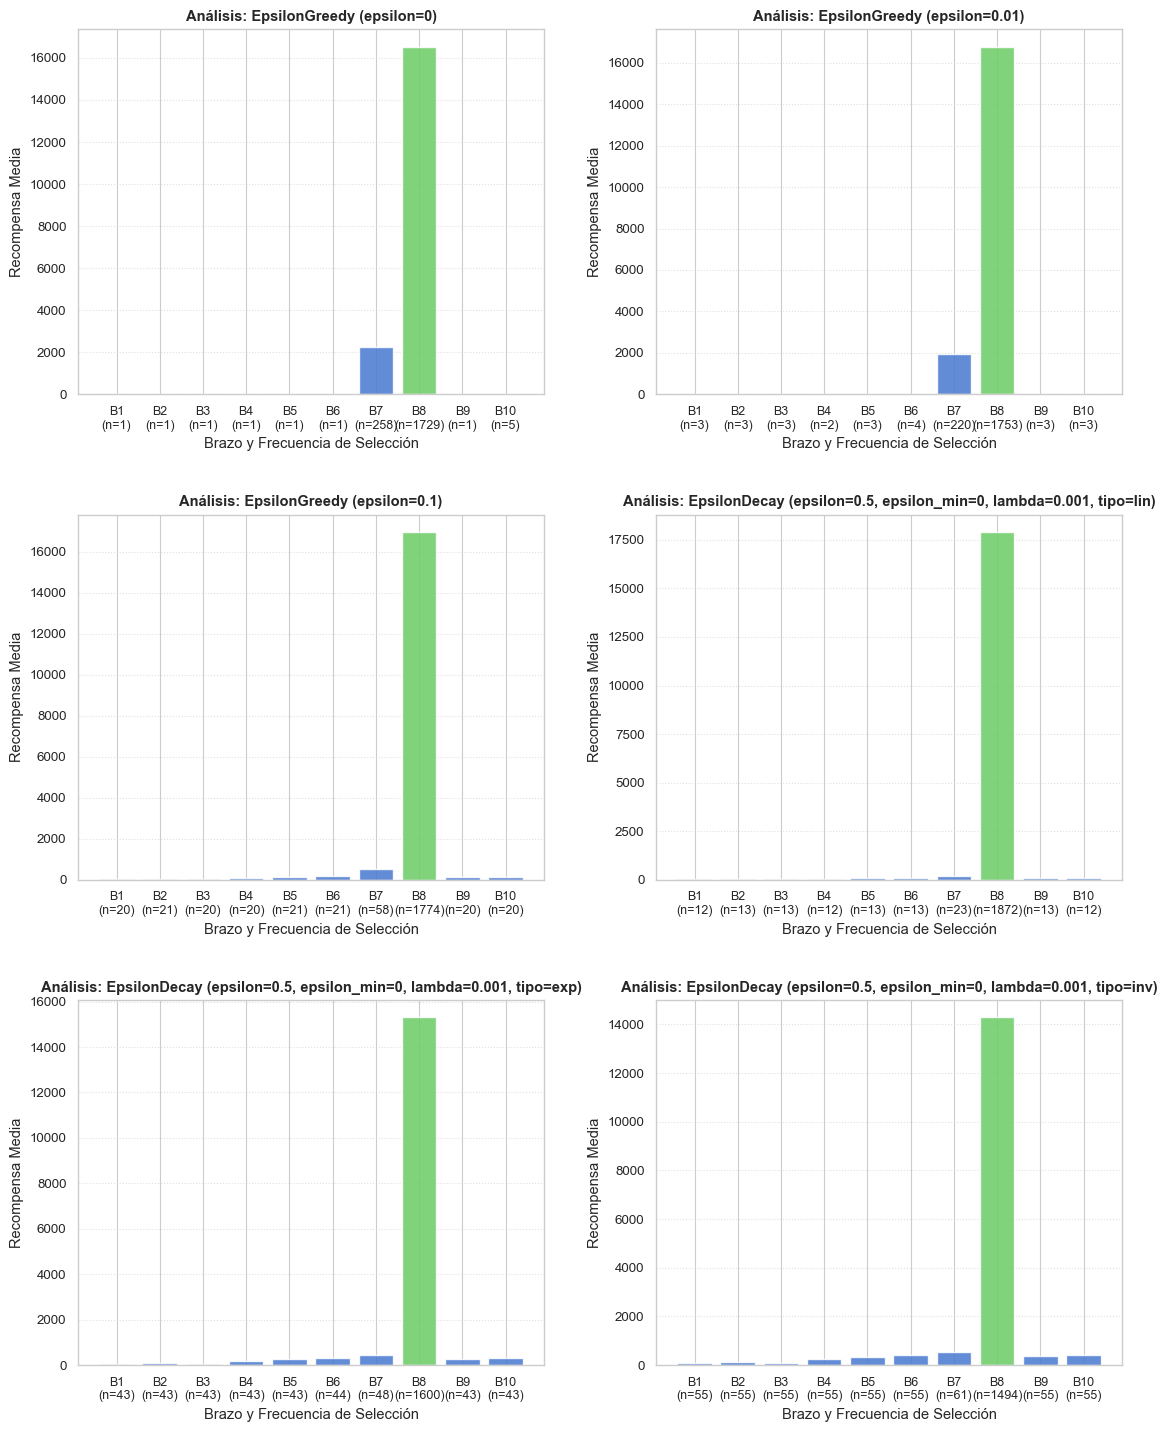

In [9]:
plot_arm_statistics(arm_stats, algorithms, k, optimal_arm)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra seis gráficos de barras, cada uno titulado **"Análisis:"**, seguido de los datos del algoritmo del que se está haciendo el análisis. En el eje **x** se representan los **brazos del bandido**, indicando en paréntesis el número de selecciones por brazo; mientras que en el eje **y** se muestra la ganancia obtenida de cada brazo. Además, la barra del brazo óptimo se muestra en verde y la del resto de brazos en azul.

1. **Las cuatro gráficas que se muestran se corresponden a diferentes configuraciones de los algoritmos $\epsilon$-greedy y $\epsilon$-decay. De izquierda a derecha y de arriba a abajo tenemos:**
   - **Primera gráfica ($\epsilon$-greedy con $\epsilon$=0):** Representa los resultados de la estrategia puramente explotadora greedy.
   - **Segunda gráfica ($\epsilon$-greedy con $\epsilon$=0.01):** Representa una estrategia exploradora del algoritmo $\epsilon$-greedy.
   - **Tercera gráfica ($\epsilon$-greedy con $\epsilon$=0.1):** Representa una estrategia más exploradora del algoritmo $\epsilon$-greedy.
   - **Cuarta gráfica ($\epsilon$-decay con decaimiento lineal):** Representa una estrategia $\epsilon$-decay donde el decaiminento aplicado es lineal.
   - **Quinta gráfica ($\epsilon$-decay con decaimiento exponencial):** Representa una estrategia $\epsilon$-decay donde el decaiminento aplicado es exponencial.
   - **Sexta gráfica ($\epsilon$-decay con decaimiento inversamente proporcional):** Representa una estrategia $\epsilon$-decay donde el decaiminento aplicado sigue una relación de proporcionalidad inversa con el número de pasos temporales transcurridos.

1. **Ganancia y número de selecciones promedio por brazo:**
   - La **primera gráfica ($\epsilon$-greedy con $\epsilon$=0)** se corresponde con la estrategia más explotadora. En ella se observa cómo el brazo B8 (el óptimo) ha sido el más elegido. El segundo brazo más elegido ha sido el brazo B7 el cual es el siguiente mejor brazo. El algoritmo parece haber estado eligiendo el brazo B7 durante varios pasos temporales hasta comprobar que la recompensa promedio del brazo B8 era superior a la del brazo B7.
   - La **segunda gráfica ($\epsilon$-greedy con $\epsilon$=0.01)** muestra que, al añadir un poco de exploración ocasional al algoritmo puramente explotador, se consigue disminuir ligeramente la cantidad de veces que se elige el brazo B7.
   - La **tercera gráfica ($\epsilon$-greedy con $\epsilon$=0.1)** muestra una disminución aún mayor en la cantidad de veces que el brazo B7 fue elegido, aunque también se observa un ligero aumento en la cantidad de veces que los demás brazos fueron elegidos, fruto de la mayor probabilidad de exploración de este algoritmo.
   - La **cuarta gráfica ($\epsilon$-decay con decaimiento lineal)** se corresponde con la estrategia $\epsilon$-decay que utiliza decaimiento lineal. Esta gráfica muestra cómo este algoritmo ha conseguido elegir el brazo óptimo más veces que los demás algoritmos, seguramente debido a la intensa exploración que se hace al principio, tras lo cual comienza progresivamente una explotación cada vez más intensiva.
   - La **quinta gráfica ($\epsilon$-decay con decaimiento exponencial) y la sexta gráfica ($\epsilon$-decay con decaimiento inversamente proporcional)** muestran cómo se elige con frecuencia brazos subóptimos debido a la lentitud en la disminución del valor de $\epsilon$.

## **Conclusiones**

En este estudio hemos analizado un **problema de toma de decisiones secuenciales** modelado mediante un **Multi-Armed Bandit (MAB)**, un marco fundamental dentro del aprendizaje por refuerzo y la teoría de decisión. En este contexto, un agente debe aprender qué acción maximiza la recompensa únicamente a partir de la experiencia obtenida durante la interacción con el entorno.

En este experimento se han evaluado distintas configuraciones de los algoritmos **$\epsilon$-greedy** y **$\epsilon$-decay** con brazos normales, comparando su comportamiento mediante varias métricas: recompensa promedio, porcentaje de selección de acción óptima y rechazo acumulado.

### **1. Exploración vs Explotación**

En este caso, los algoritmos explotadores (**$\epsilon$-greedy**) consiguen mejores resultados en el corto plazo, mientras que en el medio y largo plazo destacan los algoritmos **$\epsilon$-decay**, los cuales consiguen resultados cada vez mejores, fruto de su intensa exploración inicial.

### **2. Análisis conjunto de las métricas**

#### **Recompensa Promedio**

Los algoritmos explotadores consiguen rápidamente buenas recompensas, aunque los algoritmos exploradores son capaces de superarlas, si bien es cierto que necesitan más pasos temporales para lograrlo.

#### **Porcentaje de Acción Óptima**

Se observa que:

- Los algoritmos explotadores consiguen rápidamente un buen porcentaje, aunque este se queda estancado.
- Los algoritmos exploradores aumentan lentamente su porcentaje, pudiendo superar a los algoritmos explotadores.

#### **Rechazo Acumulado**

Esta métrica refuerza las conclusiones anteriores. Los algoritmos explotadores aumentan de forma constante su rechazo acumulado, mientras que en el caso de los algoritmos exploradores, si bien es cierto que este rechazo aumenta rápidamente durante los primeros pasos temporales, conforme avanza la ejecución consiguen disminuirlo cada vez más debido al cambio entre exploración y explotación provocado por el decaimiento de $\epsilon$.

### **3. Velocidad de Convergencia**

Los algoritmos explotadores convergen rápidamente, aunque a soluciones no tan buenas como los algoritmos exploradores, que necesitan más tiempo. Destaca el algoritmo $\epsilon$-decay con decaimiento lineal, que consigue una convergencia bastante más rápida que los otros algoritmos con decaimiento.

### **4. Interpretación práctica**

En problemas reales de toma de decisiones un equilibrio adecuado entre exploración y explotación es fundamental para maximizar el rendimiento a largo plazo. Los algoritmos $\epsilon$-greedy consiguen buenos resultados rápidamente, aunque no están tan cerca del óptimo como los resultados obtenidos por los algoritmos $\epsilon$-decay. Estos últimos algoritmos consiguen resultados muy buenos tras converger, pero necesitan más tiempo para llegar a este punto. Debido a esto, según lo que se necesite (buenos resultados pronto, o muy buenos resultados sin importar el tiempo), conviene elegir un tipo de algoritmos u otro.